# Bias Correction — What-If Diagnostic

Tests post-hoc bias correction on existing predictions without retraining.

**Goal:** Quantify how much F1/precision improves if we subtract the empirical bias
from predictions before thresholding. This is a diagnostic only.

**Three strategies:**
1. Global bias correction — subtract mean prediction error across all structures
2. Per-complexity bias correction — subtract bias per n_unique_elements group
3. Threshold sweep — vary the stability threshold, find optimal F1

Models: baseline_mean/min, stageA_mean/min 

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymatgen.core import Composition

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 120,
})
BLUE = '#4C72B0'; ORANGE = '#DD8452'; GREEN = '#55A868'; RED = '#C44E52'; GREY = '#8C8C8C'

REPO_ROOT = Path('..').resolve()
OUT_DIR   = REPO_ROOT / 'results' / 'bias_correction'
OUT_DIR.mkdir(parents=True, exist_ok=True)
HULL_THRESHOLD = 0.0

In [2]:
summary = pd.read_csv(REPO_ROOT / 'data' / 'raw' / 'wbm-summary.csv.gz')

def n_unique_elements(f):
    try: return len(Composition(f).elements)
    except: return np.nan

summary['n_unique_elements'] = summary['formula'].apply(n_unique_elements)
summary['true_stable'] = summary['e_above_hull_wbm'] <= HULL_THRESHOLD

keep = ['material_id','formula','n_sites','n_unique_elements',
        'e_form_per_atom_wbm','e_above_hull_wbm','true_stable']

pred_paths = {
    'baseline_mean' : REPO_ROOT / 'runs' / 'default'  / 'predictions_wbm.csv',
    'baseline_min'  : REPO_ROOT / 'runs' / 'default'  / 'min_tta' / 'predictions_wbm.csv',
    'stageA_mean'   : REPO_ROOT / 'runs' / 'stage_a'  / 'predictions_wbm.csv',
    'stageA_min'    : REPO_ROOT / 'runs' / 'stage_a'  / 'min_tta' / 'predictions_wbm.csv',
}

merged = {}
for name, path in pred_paths.items():
    m = pd.read_csv(path).merge(summary[keep], on='material_id', how='inner')
    m = m.dropna(subset=['e_form_pred','e_form_per_atom_wbm'])
    m['error'] = m['e_form_pred'] - m['e_form_per_atom_wbm']
    merged[name] = m
    print(f'{name}: bias={m["error"].mean()*1000:.1f} meV  MAE={m["error"].abs().mean()*1000:.1f} meV')

baseline_mean: bias=122.5 meV  MAE=168.8 meV
baseline_min: bias=-47.9 meV  MAE=110.3 meV
stageA_mean: bias=110.8 meV  MAE=159.9 meV
stageA_min: bias=-47.6 meV  MAE=109.4 meV


In [3]:
def compute_metrics(e_pred, true_stable, threshold=0.0):
    pred_stable = e_pred <= threshold
    tp = int((pred_stable & true_stable).sum())
    fp = int((pred_stable & ~true_stable).sum())
    fn = int((~pred_stable & true_stable).sum())
    tn = int((~pred_stable & ~true_stable).sum())
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    return {'f1':f1,'precision':prec,'recall':rec,'tp':tp,'fp':fp,'fn':fn,'tn':tn}

## Strategy 1 — Global bias correction

In [4]:
rows = []
for name, m in merged.items():
    bias = m['error'].mean()
    orig = compute_metrics(m['e_form_pred'], m['true_stable'])
    orig.update({'model':name,'strategy':'none'})
    corr = compute_metrics(m['e_form_pred']-bias, m['true_stable'])
    corr.update({'model':name,'strategy':f'global ({bias*1000:.0f}meV removed)'})
    rows.extend([orig, corr])

df = pd.DataFrame(rows)[['model','strategy','f1','precision','recall','fp','fn']]
display(df.round(4))

,model,strategy,f1,precision,recall,fp,fn
0,baseline_mean,none,0.3645,0.2248,0.9637,160468,1752
1,baseline_mean,global (122meV removed),0.3496,0.2126,0.9816,175473,888
2,baseline_min,none,0.3436,0.2077,0.9930,182816,339
3,baseline_min,global (-48meV removed),0.3497,0.2123,0.9897,177236,496
4,stageA_mean,none,0.3631,0.2234,0.9697,162732,1465
5,stageA_mean,global (111meV removed),0.3494,0.2124,0.9843,176191,756
6,stageA_min,none,0.3432,0.2074,0.9930,183161,340
7,stageA_min,global (-48meV removed),0.3488,0.2117,0.9895,177852,509


## Strategy 2 — Per-complexity bias correction

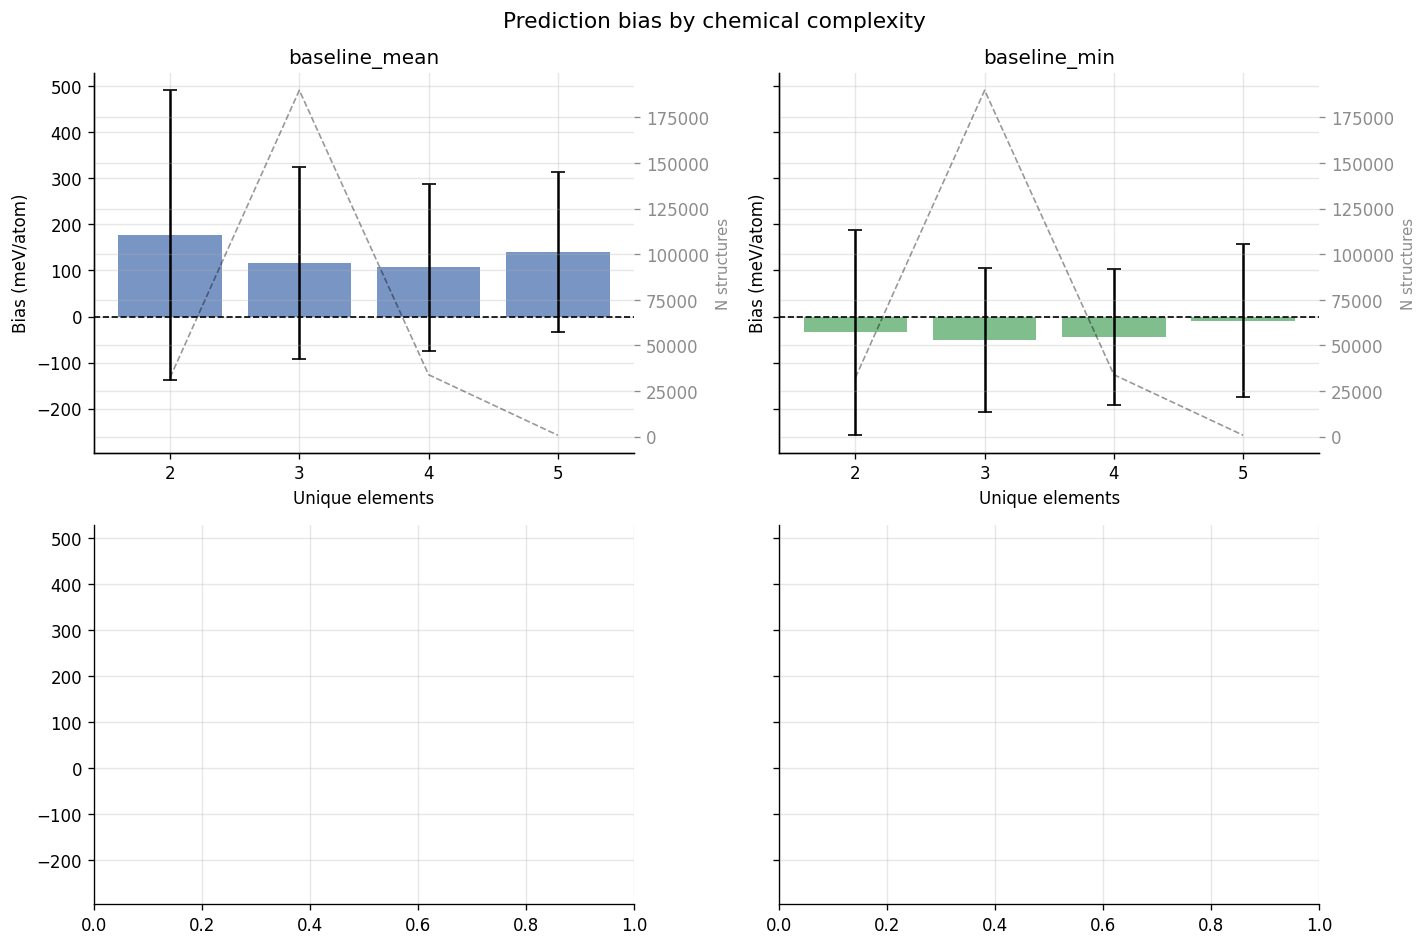

,model,strategy,f1,precision,recall,fp
0,baseline_mean,none,0.3645,0.2248,0.9637,160468
1,baseline_mean,per_element,0.3493,0.2123,0.9836,176139
2,baseline_min,none,0.3436,0.2077,0.9930,182816
3,baseline_min,per_element,0.3496,0.2123,0.9903,177395


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
rows_el = []

for ax, (name, m), color in zip(axes.flat, merged.items(), [BLUE, GREEN]):
    el_range = sorted(m['n_unique_elements'].dropna().unique())
    biases, stds, counts = [], [], []
    e_corrected = m['e_form_pred'].copy()

    for n_el in el_range:
        mask = m['n_unique_elements'] == n_el
        sub  = m[mask]
        b    = sub['error'].mean()
        biases.append(b * 1000)
        stds.append(sub['error'].std() * 1000)
        counts.append(len(sub))
        if len(sub) >= 100:
            e_corrected.loc[mask] = sub['e_form_pred'] - b

    ax.bar(el_range, biases, color=color, alpha=0.75)
    ax.errorbar(el_range, biases, yerr=stds, fmt='none', color='black', capsize=4, lw=1.5)
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xlabel('Unique elements'); ax.set_ylabel('Bias (meV/atom)')
    ax.set_title(f'{name}'); ax.set_xticks(el_range)
    ax2 = ax.twinx()
    ax2.plot(el_range, counts, 'k--', lw=1, alpha=0.4)
    ax2.set_ylabel('N structures', color=GREY, fontsize=9)
    ax2.tick_params(axis='y', colors=GREY)

    orig = compute_metrics(m['e_form_pred'], m['true_stable'])
    orig.update({'model':name,'strategy':'none'})
    corr = compute_metrics(e_corrected, m['true_stable'])
    corr.update({'model':name,'strategy':'per_element'})
    rows_el.extend([orig, corr])

fig.suptitle('Prediction bias by chemical complexity', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / '01_bias_by_complexity.png', dpi=150)
plt.show()

df_el = pd.DataFrame(rows_el)[['model','strategy','f1','precision','recall','fp']]
display(df_el.round(4))

## Strategy 3 — Threshold sweep

baseline_mean: best F1=0.3954 @ -295 meV  P=0.2604  R=0.8204
baseline_min: best F1=0.3791 @ -300 meV  P=0.2394  R=0.9105
stageA_mean: best F1=0.3934 @ -300 meV  P=0.2584  R=0.8240
stageA_min: best F1=0.3783 @ -300 meV  P=0.2387  R=0.9107


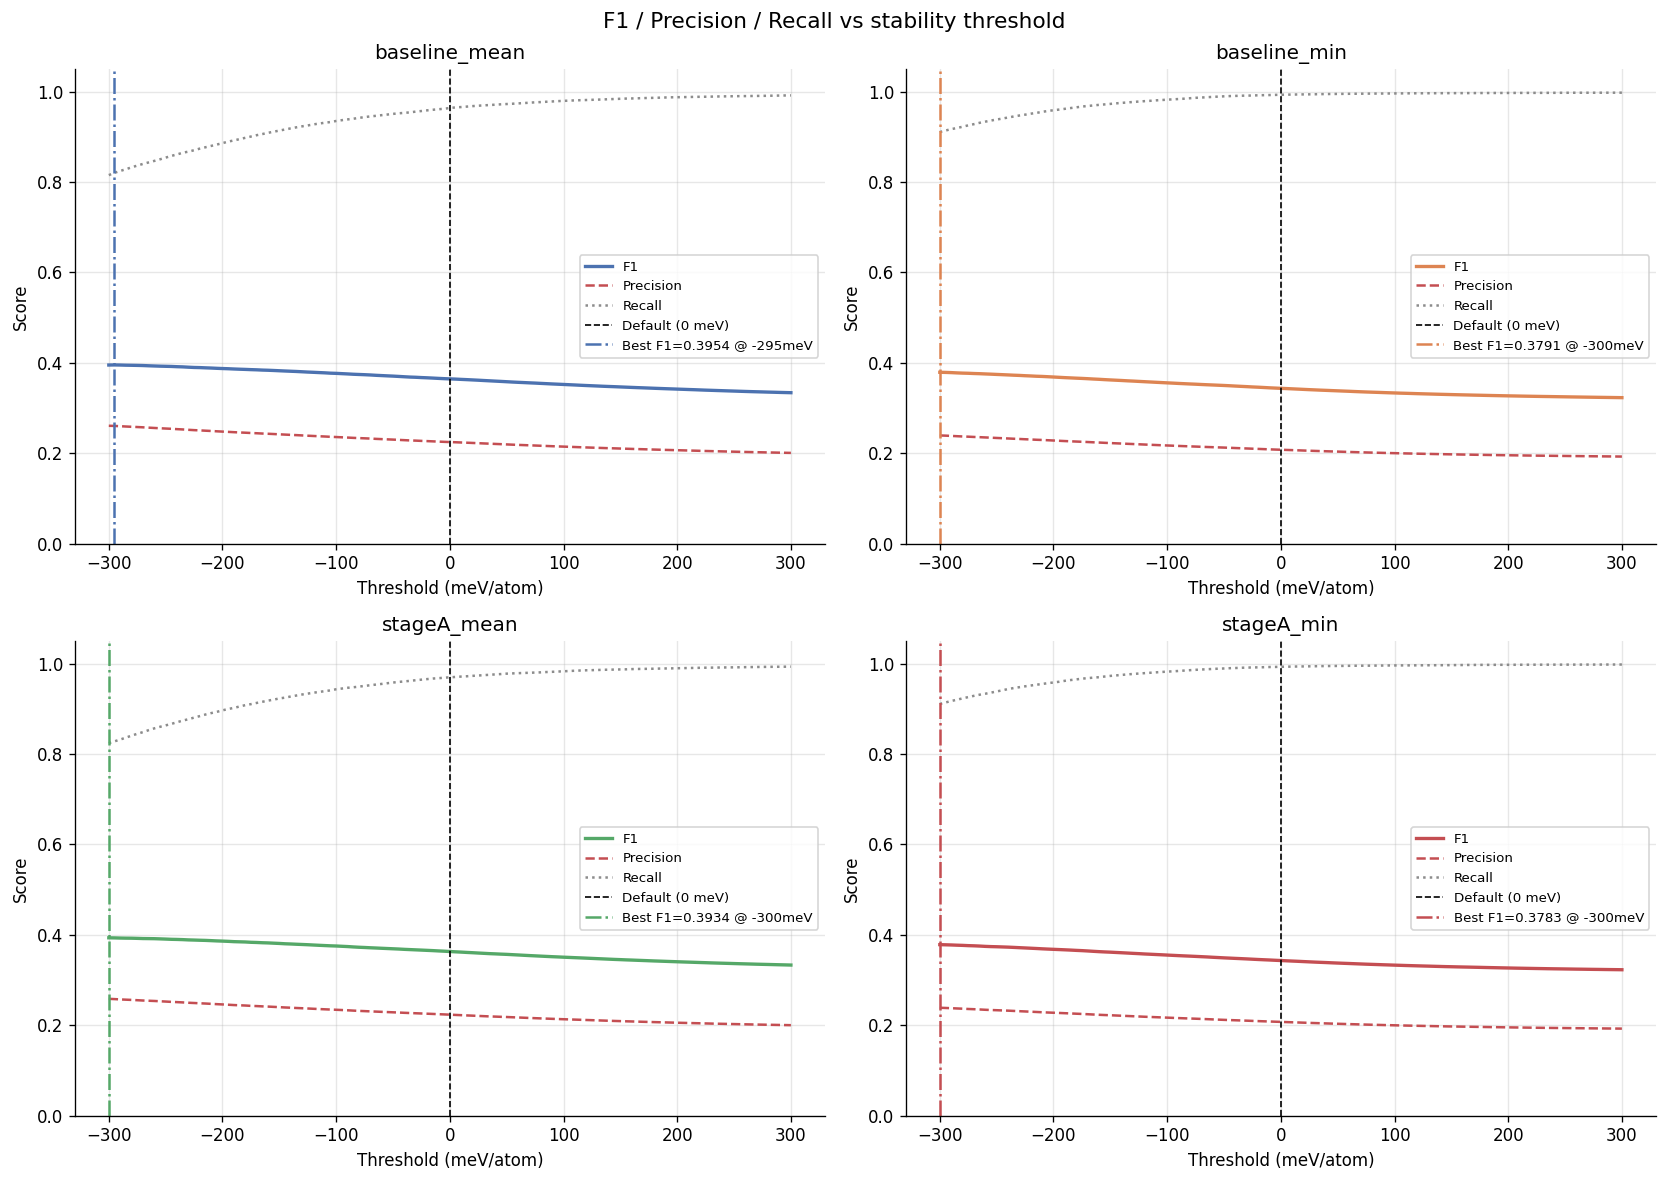

In [6]:
thresholds = np.linspace(-0.3, 0.3, 121)
fig, axes  = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, m), color in zip(axes.flat, merged.items(), [BLUE, ORANGE, GREEN, RED]):
    f1s, precs, recs = [], [], []
    for t in thresholds:
        met = compute_metrics(m['e_form_pred'], m['true_stable'], threshold=t)
        f1s.append(met['f1']); precs.append(met['precision']); recs.append(met['recall'])

    best_idx = int(np.argmax(f1s))
    best_t   = thresholds[best_idx]

    ax.plot(thresholds*1000, f1s,   color=color, lw=2,   label='F1')
    ax.plot(thresholds*1000, precs, color=RED,   lw=1.5, ls='--', label='Precision')
    ax.plot(thresholds*1000, recs,  color=GREY,  lw=1.5, ls=':',  label='Recall')
    ax.axvline(0,           color='black', lw=1,   ls='--', label='Default (0 meV)')
    ax.axvline(best_t*1000, color=color,  lw=1.5, ls='-.',
               label=f'Best F1={f1s[best_idx]:.4f} @ {best_t*1000:.0f}meV')
    ax.set_xlabel('Threshold (meV/atom)'); ax.set_ylabel('Score')
    ax.set_title(f'{name}'); ax.legend(fontsize=8); ax.set_ylim(0, 1.05)
    print(f'{name}: best F1={f1s[best_idx]:.4f} @ {best_t*1000:.0f} meV  '
          f'P={precs[best_idx]:.4f}  R={recs[best_idx]:.4f}')

fig.suptitle('F1 / Precision / Recall vs stability threshold', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / '02_threshold_sweep.png', dpi=150)
plt.show()

## Summary table

In [7]:
summary_rows = []
for name, m in merged.items():
    bias = m['error'].mean()
    thresholds_fine = np.linspace(-0.3, 0.3, 601)
    f1s = [compute_metrics(m['e_form_pred'], m['true_stable'], t)['f1'] for t in thresholds_fine]
    best_t = thresholds_fine[int(np.argmax(f1s))]

    for label, e_pred, thresh in [
        ('original',           m['e_form_pred'],        0.0),
        ('global_correction',  m['e_form_pred'] - bias,  0.0),
        ('optimal_threshold',  m['e_form_pred'],         best_t),
    ]:
        met = compute_metrics(e_pred, m['true_stable'], thresh)
        summary_rows.append({'model':name, 'strategy':label,
                             'f1':round(met['f1'],4),
                             'precision':round(met['precision'],4),
                             'recall':round(met['recall'],4),
                             'fp':met['fp'], 'fn':met['fn']})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(OUT_DIR / '03_bias_correction_summary.csv', index=False)
print('Saved: 03_bias_correction_summary.csv')
print()
print('NOTE: Global correction and optimal threshold are post-hoc patches.')
print('They show the ceiling of what calibration alone can achieve.')
print('If optimal_threshold F1 >> original F1: calibration is worth pursuing.')
print('If gap is small: retraining is necessary.')

,model,strategy,f1,precision,recall,fp,fn
0,baseline_mean,original,0.3645,0.2248,0.9637,160468,1752
1,baseline_mean,global_correction,0.3496,0.2126,0.9816,175473,888
2,baseline_mean,optimal_threshold,0.3954,0.2604,0.8204,112469,8671
3,baseline_min,original,0.3436,0.2077,0.9930,182816,339
4,baseline_min,global_correction,0.3497,0.2123,0.9897,177236,496
5,baseline_min,optimal_threshold,0.3791,0.2394,0.9114,139824,4276
6,stageA_mean,original,0.3631,0.2234,0.9697,162732,1465
7,stageA_mean,global_correction,0.3494,0.2124,0.9843,176191,756
8,stageA_mean,optimal_threshold,0.3934,0.2584,0.8240,114154,8497
9,stageA_min,original,0.3432,0.2074,0.9930,183161,340


Saved: 03_bias_correction_summary.csv

NOTE: Global correction and optimal threshold are post-hoc patches.
They show the ceiling of what calibration alone can achieve.
If optimal_threshold F1 >> original F1: calibration is worth pursuing.
If gap is small: retraining is necessary.
